# 1. Exploratory data analysis

Dataset composition, export formats, recording length and behaviour, age, signal quality and spectra. Group comparisons here are descriptive: model features were chosen from the literature (section 1.10), not from these plots.

Sections 1.1 to 1.10 cover the original release (166 subjects). Section 1.11 covers the two later batches: 23 controls aged 65+ and 40 young controls.

In [1]:
import sys
import warnings
from pathlib import Path

ROOT = Path.cwd().resolve().parent if Path.cwd().name == "results" else Path.cwd().resolve()
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src import config, dataset, diagnostics, features, preprocessing, viz

warnings.filterwarnings("ignore", message="All-NaN slice encountered")
warnings.filterwarnings("ignore", message="Mean of empty slice")
viz.apply_style()
pd.set_option("display.precision", 2)
COHORTS = list(config.GROUPS)
cfg = preprocessing.PreprocessingConfig()

## 1.1 Composition and integrity

Byte-identical recordings link subject IDs into independent groups (`split_group`). These groups are the unit of every train/test split.

In [2]:
registry_all, links, subjects_all = dataset.scan_dataset(config.DATA_DIR)
original = subjects_all.index[~subjects_all["holdout"] & subjects_all["has_task_files"]]
registry = registry_all[registry_all["subject_key"].isin(original)].copy()
subjects = subjects_all.loc[original].copy()
ok = registry[registry["status"] == "ok"]

summary = registry.groupby("group").agg(
    subjects=("subject_id", "nunique"),
    files=("relpath", "size"),
    non_empty=("status", lambda s: (s == "ok").sum()),
).reindex(COHORTS)
summary["independent groups"] = subjects.groupby("group")["split_group"].nunique().reindex(COHORTS)
viz.english(summary)

,subjects,files,non_empty,independent groups
group,,,,
control,67,402,402,67
PTSD,25,150,150,24
somatoform,74,444,439,67


In [3]:
print("Empty files:", [viz.english(p) for p in registry.loc[registry["status"] != "ok", "relpath"]])
print("Header n_records = -1:", int((ok["n_records_header"] == -1).sum()), "files, read by file size")
same = links["subject_a"] == links["subject_b"]
print(f"Links by identical content: {len(links)} (between different IDs: {(~same).sum()}, within one ID: {same.sum()})")
links[["relpath_a", "relpath_b"]].map(viz.english)

Empty files: ['somatoform/XCFU5/T-1.edf', 'somatoform/XCFU5/T-2.edf', 'somatoform/XCFU5/T-3.edf', 'somatoform/XCFU5/T-4.edf', 'somatoform/XCFU5/T-5.edf']
Header n_records = -1: 9 files, read by file size
Links by identical content: 27 (between different IDs: 22, within one ID: 5)


,relpath_a,relpath_b
0,PTSD/DFGH/T-П.edf,PTSD/WSXD/T-1.edf
1,somatoform/DFGH8/T-2.edf,somatoform/DFGH8/T-3.edf
2,somatoform/DIKL0/T-1.edf,somatoform/GHRD3/T-П.edf
3,somatoform/DIKL0/T-2.edf,somatoform/GHRD3/T-1.edf
4,somatoform/DIKL0/T-3.edf,somatoform/GHRD3/T-2.edf
5,somatoform/DIKL0/T-4.edf,somatoform/GHRD3/T-3.edf
6,somatoform/KGBT5/T-4.edf,somatoform/KGBT5/T-5.edf
7,somatoform/KRTM8/T-5.edf,somatoform/PYVB0/T-5.edf
8,somatoform/LDPR3/T-3.edf,somatoform/ZILO6/T-4.edf
9,somatoform/LDPR3/T-4.edf,somatoform/ZILO6/T-5.edf


Some copies appear both as rest and as a task trial (`condition_conflict`). Their condition is unknown, so they are not used for features of either condition.

In [4]:
viz.english(registry.loc[registry["condition_conflict"], ["relpath", "condition", "duplicate_set"]].sort_values("duplicate_set")).assign(
    relpath=lambda d: d["relpath"].map(viz.english))

,relpath,condition,duplicate_set
792,PTSD/DFGH/T-П.edf,rest,797
919,PTSD/WSXD/T-1.edf,task,797
985,somatoform/DIKL0/T-1.edf,task,982
1044,somatoform/GHRD3/T-П.edf,rest,982
1103,somatoform/LDPR3/T-5.edf,task,1095
1350,somatoform/ZILO6/T-П.edf,rest,1095
1260,somatoform/TMVN4/T-П.edf,rest,1230
1241,somatoform/SIGO3/T-5.edf,task,1230
1265,somatoform/TMVN4/T-5.edf,task,1230
1326,somatoform/XYKT7/T-П.edf,rest,1305


Format B pads the end of a recording with zeros (`edge_constant_s`). Left as is, this would create a step in the last window of almost every PTSD recording, so preprocessing trims such edges.

In [5]:
viz.english(ok.assign(padded=ok["edge_constant_s"] >= 0.1).groupby(["group", "export_family"]).agg(
    files=("relpath", "size"), padded_edge=("padded", "sum"), median_s=("edge_constant_s", "median"),
    max_s=("edge_constant_s", "max"), interior_max_s=("interior_constant_s", "max")))

files  padded_edge  median_s  max_s  interior_max_s
group      export_family                                                     
control    A                120            0      0.00   0.00             0.0
           B                 12           12      0.69   0.89             0.0
           C                270            0      0.00   0.00             0.0
PTSD       B                150          138      0.52   0.98             0.0
somatoform A                439            0      0.00   0.00             0.0

## 1.2 Export formats

The amplitude step `Δ = (P_max − P_min)/(D_max − D_min)` is computed per file. The format is never given to the model; it is used to check whether the model detects the export instead of physiology.

In [6]:
family = ok.groupby("subject_key")["export_family"].agg(lambda s: "".join(sorted(set(s))))
subjects["export_family"] = family.reindex(subjects.index)
fam_table = pd.crosstab(subjects["group"], subjects["export_family"]).reindex(COHORTS)
fam_table.columns = [f"format {c}" for c in fam_table.columns]
viz.english(fam_table)

,format A,format B,format C
group,,,
control,20,2,45
PTSD,0,25,0
somatoform,74,0,0


In [7]:
(ok.groupby("export_family")
   .agg(step_uv_min=("quant_step_uv", "min"), step_uv_max=("quant_step_uv", "max"),
        range_max_uv=("physical_max", "max"), sfreq_hz=("sfreq", lambda s: sorted(s.unique())),
        share_bs50=("notch_50", "mean"), files=("relpath", "size")))

,step_uv_min,step_uv_max,range_max_uv,sfreq_hz,share_bs50,files
export_family,,,,,,
A,1.00e+00,1.00,32767.0,[125.0],1.0,559
B,6.10e-02,0.06,2000.0,[125.0],1.0,162
C,2.70e-03,0.02,871.0,"[123.0, 124.0, 125.0, 126.0, 127.0]",0.0,270


AUC of the rule "format B means PTSD", without any signal analysis:

In [8]:
from sklearn.metrics import roc_auc_score

pair = subjects[subjects["group"].isin([config.GROUP_CONTROL, config.GROUP_PTSD])]
no_c = pair[pair["export_family"] != "C"]
print(f"AUC of the format B rule: all controls {roc_auc_score(pair['label'], pair['export_family'] == 'B'):.3f}; "
      f"controls A and B only {roc_auc_score(no_c['label'], no_c['export_family'] == 'B'):.3f}")

AUC of the format B rule: all controls 0.985; controls A and B only 0.955


## 1.3 Sampling rate and recording length

In [9]:
viz.english(pd.crosstab(ok["group"], ok["sfreq"]).reindex(COHORTS))

sfreq,123.0,124.0,125.0,126.0,127.0
group,,,,,
control,47,52,194,58,51
PTSD,0,0,150,0,0
somatoform,0,0,439,0,0


In [10]:
viz.english(ok.groupby(["condition", "group"])["active_duration_s"].describe()[["count", "min", "25%", "50%", "75%", "max"]])

count    min    25%    50%    75%     max
condition group                                                
rest      control      67.0  60.00  61.00  61.00  61.00   65.00
          PTSD         25.0  34.51  60.55  61.32  61.51   65.50
          somatoform   74.0  32.00  60.00  61.00  63.00  121.00
task      control     335.0  17.00  36.00  41.00  52.00  133.00
          PTSD        125.0   7.66  44.66  54.55  73.54  122.52
          somatoform  365.0   1.00  35.00  43.00  52.00  142.00

The length of a task recording is the time spent solving a Schulte table. In format C all five trials of a subject have the same length, so for them it is not a solve time, and behaviour is compared without format C.

In [11]:
per_subject_task = ok[ok["condition"] == "task"].groupby(["group", "export_family", "subject_key"])["active_duration_s"]
templated = per_subject_task.nunique().eq(1).groupby(level=[0, 1]).agg(["sum", "size"])
templated.columns = ["subjects with five equal trial lengths", "all subjects"]
c_task = ok[(ok["export_family"] == "C") & (ok["condition"] == "task")]
print("Format C, trial lengths (s):", c_task.groupby("subject_key")["active_duration_s"].first().value_counts().sort_index().to_dict())
viz.english(templated)

Format C, trial lengths (s): {34.0: 8, 36.0: 5, 41.0: 14, 52.0: 7, 53.0: 11}


subjects with five equal trial lengths  all subjects
group      export_family                                                      
control    A                                                   0            20
           B                                                   0             2
           C                                                  45            45
PTSD       B                                                   0            25
somatoform A                                                   0            73

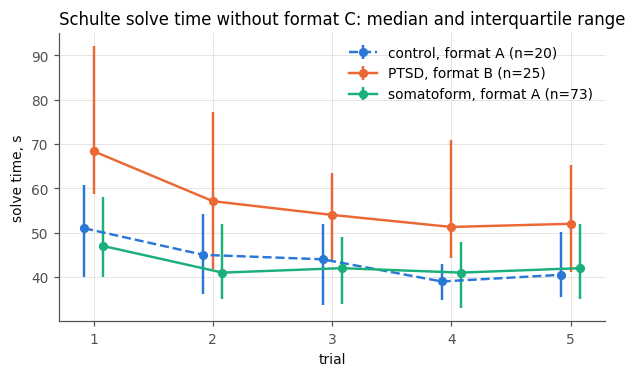

trial                         1      2      3      4      5
group      export_family                                   
control    A              51.00  45.00  44.00  39.00  40.50
           B              37.57  33.64  31.72  40.72  35.84
           C              41.00  41.00  41.00  41.00  41.00
PTSD       B              68.35  57.10  54.00  51.29  52.00
somatoform A              47.00  41.00  42.00  41.00  42.00

In [12]:
task = ok[ok["condition"] == "task"]
strata_beh = [(config.GROUP_CONTROL, "A", "--"), (config.GROUP_PTSD, "B", "-"), (config.GROUP_SOMATOFORM, "A", "-")]
fig, ax = plt.subplots(figsize=(6.4, 3.4))
for i, (cohort, fam, style) in enumerate(strata_beh):
    d = task[(task["group"] == cohort) & (task["export_family"] == fam)]
    q = d.groupby("trial")["active_duration_s"].quantile([0.25, 0.5, 0.75]).unstack()
    x = q.index + (i - 1) * 0.08
    ax.errorbar(x, q[0.5], yerr=[q[0.5] - q[0.25], q[0.75] - q[0.5]], color=viz.COHORT_COLORS[cohort], ls=style,
                marker="o", ms=5, capsize=0, lw=1.6, label=f"{viz.english(cohort)}, format {fam} (n={d['subject_key'].nunique()})")
ax.set_xticks(range(1, 6))
ax.set_xlabel("trial")
ax.set_ylabel("solve time, s")
ax.set_title("Schulte solve time without format C: median and interquartile range", loc="left")
ax.legend()
plt.show()
viz.english(task.pivot_table(index=["group", "export_family"], columns="trial", values="active_duration_s", aggfunc="median"))

## 1.4 Age

Age is known only for controls (from the folder name). According to the task description, PTSD patients are men aged 18 to 45 and somatoform patients are 18 to 45 of both sexes.

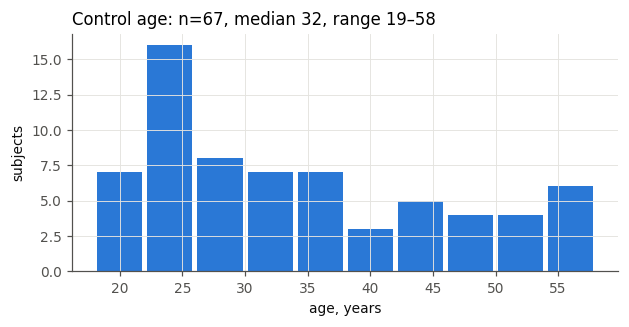

export_family,A,B,C
age,,,
18–29,15,0,16
30–45,3,2,17
46–64,2,0,12


In [13]:
ages = subjects.loc[subjects["group"] == config.GROUP_CONTROL, "age"]
fig, ax = plt.subplots(figsize=(6.4, 2.8))
ax.hist(ages, bins=np.arange(18, 62, 4), color=viz.COHORT_COLORS[config.GROUP_CONTROL], rwidth=0.9)
ax.set_xlabel("age, years")
ax.set_ylabel("subjects")
ax.set_title(f"Control age: n={ages.size}, median {ages.median():.0f}, range {ages.min():.0f}–{ages.max():.0f}", loc="left")
plt.show()
controls = subjects[subjects["group"] == config.GROUP_CONTROL]
pd.crosstab(pd.cut(controls["age"], [18, 29, 45, 64], labels=["18–29", "30–45", "46–64"]), controls["export_family"])

## 1.5 Quality: window rejection

Windows are 4 s long with a 2 s step. Each window and channel pair is flagged with the same thresholds for everyone: flat signal, clipping, amplitude range above 400 µV, outlying variance and dropout.

In [14]:
qc = preprocessing.rejection_table(registry, cfg).merge(
    registry[["relpath", "group", "condition", "export_family", "subject_key"]], on="relpath")
qc["frac_good"] = qc["n_good"] / qc["n_windows"].replace(0, np.nan)
flag_cols = ["frac_good", "frac_flat", "frac_rail", "frac_amplitude", "frac_variance", "frac_dropout"]
viz.english(qc.groupby(["condition", "group"])[flag_cols].mean())

frac_good  frac_flat  frac_rail  frac_amplitude  \
condition group                                                         
rest      control          0.98        0.0   0.00e+00        6.34e-03   
          PTSD             0.87        0.0   3.22e-02        7.81e-02   
          somatoform       0.75        0.0   2.22e-03        2.10e-01   
task      control          0.94        0.0   0.00e+00        3.79e-02   
          PTSD             0.86        0.0   3.71e-02        9.27e-02   
          somatoform       0.73        0.0   1.33e-03        2.29e-01   

                      frac_variance  frac_dropout  
condition group                                    
rest      control              0.02           0.0  
          PTSD                 0.10           0.0  
          somatoform           0.17           0.0  
task      control              0.05           0.0  
          PTSD                 0.11           0.0  
          somatoform           0.17           0.0

In [15]:
viz.english(qc.pivot_table(index=["condition", "group"], columns="channel", values="frac_good")[list(config.CHANNELS)])

channel                 O1    T3   Fp1   Fp2    T4    O2
condition group                                         
rest      control     0.97  0.97  0.99  0.99  0.99  0.99
          PTSD        0.88  0.88  0.86  0.90  0.87  0.86
          somatoform  0.80  0.64  0.80  0.82  0.63  0.80
task      control     0.96  0.91  0.99  0.99  0.84  0.93
          PTSD        0.90  0.82  0.87  0.91  0.84  0.84
          somatoform  0.79  0.61  0.78  0.79  0.61  0.77

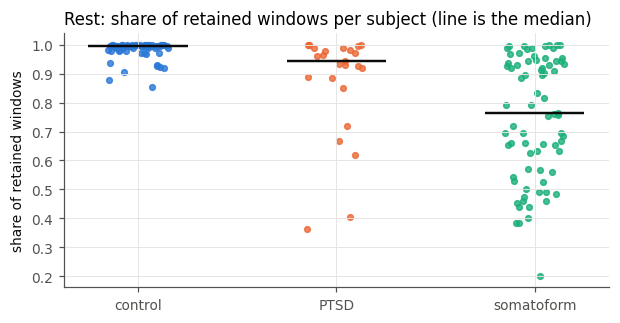

export_family
A    0.95
B    0.98
C    1.00
Name: controls at rest: retained windows, dtype: float64

In [16]:
rest_qc = qc[qc["condition"] == "rest"]
per_subject = rest_qc.groupby(["group", "subject_key"])["frac_good"].mean()
fig, ax = plt.subplots(figsize=(6.4, 3.0))
for i, cohort in enumerate(COHORTS):
    v = per_subject.loc[cohort].to_numpy()
    jitter = np.random.default_rng(0).uniform(-0.15, 0.15, v.size)
    ax.scatter(i + jitter, v, s=14, color=viz.COHORT_COLORS[cohort], alpha=0.8)
    ax.hlines(np.median(v), i - 0.25, i + 0.25, color="#0b0b0b", lw=1.6)
ax.set_xticks(range(3), [viz.english(c) for c in COHORTS])
ax.set_ylabel("share of retained windows")
ax.set_title("Rest: share of retained windows per subject (line is the median)", loc="left")
plt.show()
rest_qc[rest_qc["group"] == config.GROUP_CONTROL].groupby("export_family")["frac_good"].mean().rename("controls at rest: retained windows")

## 1.6 Example signals

The first 10 s of rest after resampling and the 40 Hz low-pass filter, one subject of typical quality per group. Below are the first Schulte trial and a recording with strong artefacts.

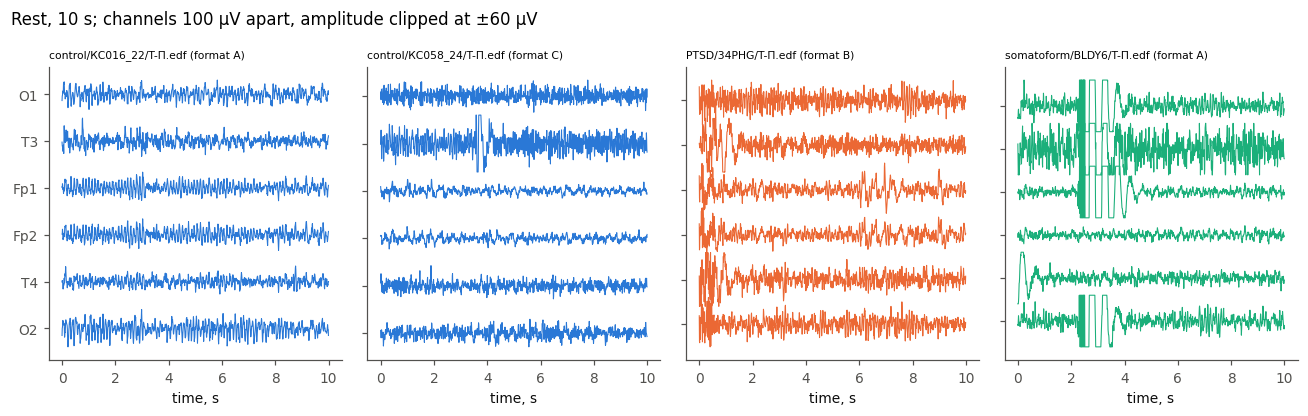

In [17]:
def conditioned(relpath: str) -> np.ndarray:
    rec = dataset.load_record(config.DATA_DIR / relpath)
    x = preprocessing.resample(rec.data, rec.sfreq, cfg.target_sfreq)
    return preprocessing.lowpass(x, cfg.target_sfreq, cfg.lowpass_hz)

def typical_rest(cohort: str, fam: str) -> str:
    rec_quality = rest_qc[(rest_qc["group"] == cohort) & (rest_qc["export_family"] == fam)].groupby("relpath")["frac_good"].mean()
    return (rec_quality - rec_quality.median()).abs().sort_values(kind="stable").index[0]

panels = [(config.GROUP_CONTROL, "A"), (config.GROUP_CONTROL, "C"), (config.GROUP_PTSD, "B"), (config.GROUP_SOMATOFORM, "A")]
fig, axes = plt.subplots(1, 4, figsize=(12, 3.8))
for ax, (cohort, fam) in zip(axes, panels):
    relpath = typical_rest(cohort, fam)
    viz.plot_traces(ax, np.clip(conditioned(relpath)[:, : 10 * 125], -60, 60), cfg.target_sfreq,
                    spacing_uv=100, color=viz.COHORT_COLORS[cohort])
    ax.set_title(f"{viz.english(relpath)} (format {fam})", loc="left", fontsize=7)
    ax.label_outer()
fig.suptitle("Rest, 10 s; channels 100 µV apart, amplitude clipped at ±60 µV", x=0.01, ha="left")
plt.tight_layout()
plt.show()

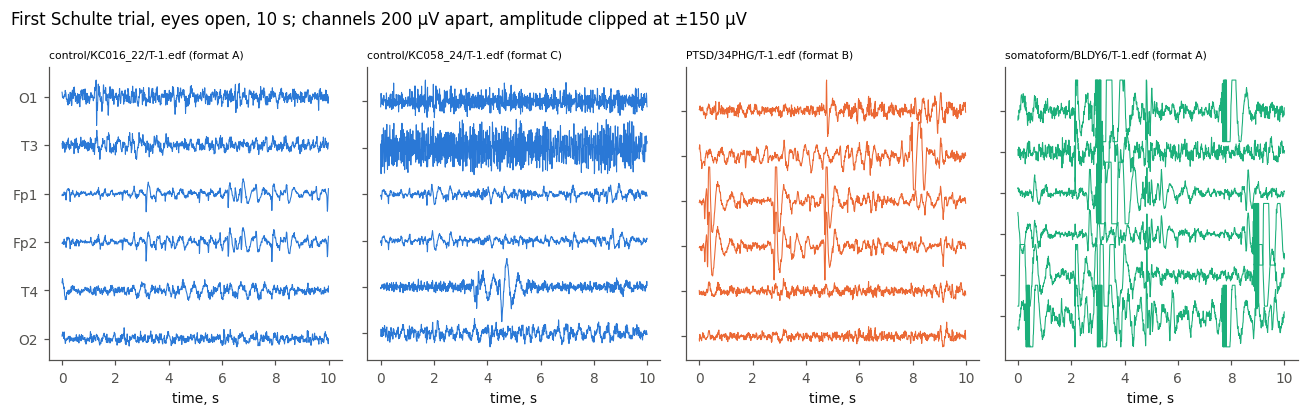

In [18]:
fig, axes = plt.subplots(1, 4, figsize=(12, 3.8))
for ax, (cohort, fam) in zip(axes, panels):
    subject_key = typical_rest(cohort, fam).rsplit("/", 1)[0]
    relpath = ok.loc[(ok["subject_key"] == subject_key) & (ok["stem"] == "T-1"), "relpath"].iloc[0]
    viz.plot_traces(ax, np.clip(conditioned(relpath)[:, : 10 * 125], -150, 150), cfg.target_sfreq,
                    spacing_uv=200, color=viz.COHORT_COLORS[cohort])
    ax.set_title(f"{viz.english(relpath)} (format {fam})", loc="left", fontsize=7)
    ax.label_outer()
fig.suptitle("First Schulte trial, eyes open, 10 s; channels 200 µV apart, amplitude clipped at ±150 µV",
             x=0.01, ha="left")
plt.tight_layout()
plt.show()

With eyes open, alpha weakens and the frontal and temporal channels pick up blinks, saccades and movement, so more windows are rejected during the task.

SD per channel, µV: {'O1': 24, 'T3': 937, 'Fp1': 22, 'Fp2': 24, 'T4': 3296, 'O2': 33}


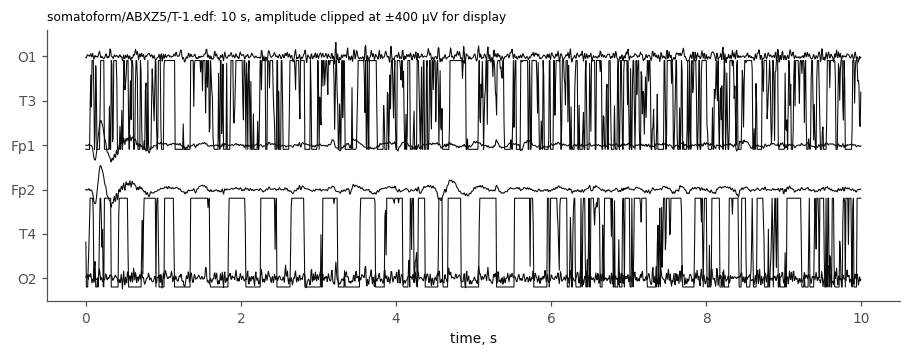

In [19]:
bad = config.GROUP_SOMATOFORM + "/ABXZ5/T-1.edf"
x = conditioned(bad)
print("SD per channel, µV:", {ch: round(float(s)) for ch, s in zip(config.CHANNELS, x.std(axis=1))})
fig, ax = plt.subplots(figsize=(10, 3.2))
viz.plot_traces(ax, np.clip(x[:, : 10 * 125], -400, 400), cfg.target_sfreq, spacing_uv=400)
ax.set_title(f"{viz.english(bad)}: 10 s, amplitude clipped at ±400 µV for display", loc="left", fontsize=8)
plt.show()

## 1.7 Spectrum by export format (no low-pass filter)

Median over channels. The dotted line is the quantisation noise for Δ = 1 µV. Above 40 Hz the spectrum depends on the format, so this range is not used for features.

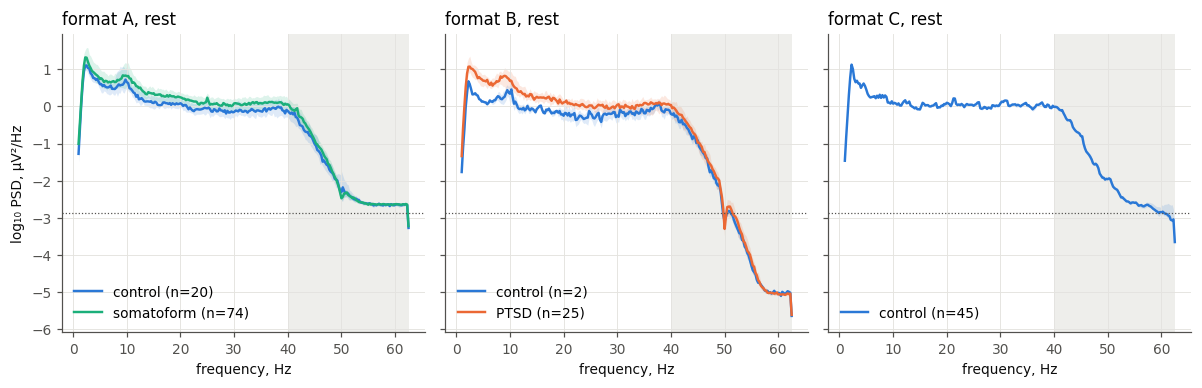

In [20]:
spec_diag = features.compute_spectra(registry, preprocessing.PreprocessingConfig(lowpass_hz=None))
meta = registry.set_index("relpath").loc[list(spec_diag.relpaths)]
per_record = np.nanmedian(spec_diag.spectra, axis=1)
f = spec_diag.freqs
keep = f >= 1.0

fig, axes = plt.subplots(1, 3, figsize=(11, 3.6), sharey=True)
for ax, fam in zip(axes, ["A", "B", "C"]):
    for cohort in COHORTS:
        sel = ((meta["export_family"] == fam) & (meta["group"] == cohort) & (meta["condition"] == "rest")).to_numpy()
        if sel.sum():
            viz.plot_median_spectra(ax, f[keep], per_record[sel][:, keep], viz.english(cohort), viz.COHORT_COLORS[cohort])
    viz.shade_unused_band(ax, 40.0, 62.5)
    ax.axhline(np.log10(1 / 12 / 62.5), color=viz.TEXT_MUTED, lw=0.8, ls=":")
    ax.set_title(f"format {fam}, rest", loc="left")
    ax.legend(loc="lower left")
    ax.label_outer()
plt.tight_layout()
plt.show()

## 1.8 Typical properties of EEG

1. Symmetric channels are correlated because of the shared ear reference and volume conduction.
2. At rest with eyes closed there is an alpha peak at O1 and O2. Its prominence is the maximum of log₁₀ PSD in 8–13 Hz minus the mean over 5–7 and 14–17 Hz; a value of 0.4 means a peak 2.5 times above its surroundings.

We also show the amplitude of T3 relative to the other channels. T3 is closest to the reference on the left ear, so the ratio should be below 1.

In [21]:
plaus_all = diagnostics.plausibility_table(registry, cfg).merge(
    registry[["relpath", "group", "export_family", "subject_key", "condition", "subject_id"]], on="relpath")
plaus = plaus_all[plaus_all["condition"] == "rest"]
pair_cols = ["O1-O2", "Fp1-Fp2", "T3-T4"]
keys = ["group", "export_family"]
table = plaus.groupby(keys)[pair_cols + ["alpha_prominence_occ", "t3_rms_ratio"]].median()
table["share with alpha peak > 0.4"] = plaus.groupby(keys)["alpha_prominence_occ"].apply(lambda v: (v > 0.4).mean())
table["recordings"] = plaus.groupby(keys).size()
viz.english(table)

O1-O2  Fp1-Fp2  T3-T4  alpha_prominence_occ  \
group      export_family                                                   
control    A              5.03e-01     0.84   0.11                  0.91   
           B              6.12e-01     0.80   0.15                  1.15   
           C             -8.97e-04     0.02   0.01                  0.19   
PTSD       B              6.13e-01     0.89   0.21                  0.83   
somatoform A              5.21e-01     0.78   0.16                  0.74   

                          t3_rms_ratio  share with alpha peak > 0.4  \
group      export_family                                              
control    A                      0.81                         0.80   
           B                      0.81                         0.50   
           C                      2.79                         0.00   
PTSD       B                      0.84                         0.88   
somatoform A                      0.97                         0.81   

                          recordings  
group      export_family              
control    A                      20  
           B                       2  
           C                      45  
PTSD       B                      25  
somatoform A                      74

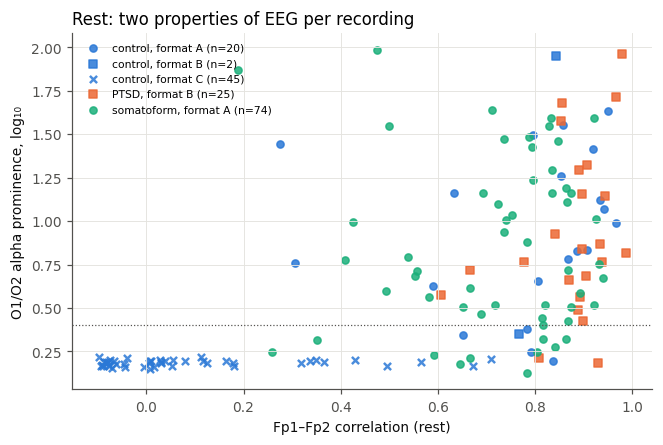

In [22]:
fig, ax = plt.subplots(figsize=(6.8, 4.2))
markers = {"A": "o", "B": "s", "C": "x"}
for cohort in COHORTS:
    for fam, marker in markers.items():
        d = plaus[(plaus["group"] == cohort) & (plaus["export_family"] == fam)]
        if len(d):
            ax.scatter(d["Fp1-Fp2"], d["alpha_prominence_occ"], s=22, marker=marker, color=viz.COHORT_COLORS[cohort],
                       alpha=0.85, label=f"{viz.english(cohort)}, format {fam} (n={len(d)})")
ax.axhline(0.4, color=viz.TEXT_MUTED, lw=0.8, ls=":")
ax.set_xlabel("Fp1–Fp2 correlation (rest)")
ax.set_ylabel("O1/O2 alpha prominence, log₁₀")
ax.set_title("Rest: two properties of EEG per recording", loc="left")
ax.legend(fontsize=7, loc="upper left")
plt.show()

If format C rest had been recorded with eyes open, that would explain the missing alpha but not the missing Fp1–Fp2 correlation, because blinks appear on both frontal channels at once. Below are the same properties during the task, when the eyes are open.

In [23]:
viz.english(plaus_all[plaus_all["condition"] == "task"].groupby(keys)[pair_cols + ["t3_rms_ratio"]].median())

O1-O2  Fp1-Fp2     T3-T4  t3_rms_ratio
group      export_family                                           
control    A              4.63e-01     0.87  1.35e-01          0.79
           B              4.96e-01     0.92  1.30e-01          1.07
           C             -6.61e-03     0.10  9.25e-04          2.78
PTSD       B              6.07e-01     0.88  2.37e-01          0.82
somatoform A              5.72e-01     0.83  2.06e-01          0.96

In [24]:
low_alpha = plaus[(plaus["group"] == config.GROUP_CONTROL) & (plaus["alpha_prominence_occ"] < 0.3)]
print(f"Controls at rest with alpha prominence < 0.3: {len(low_alpha)} recordings; by format:", low_alpha["export_family"].value_counts().to_dict())
low_alpha[low_alpha["export_family"] != "C"][["subject_id", "export_family", "alpha_prominence_occ", "Fp1-Fp2", "O1-O2"]]

Controls at rest with alpha prominence < 0.3: 47 recordings; by format: {'C': 45, 'A': 2}


,subject_id,export_family,alpha_prominence_occ,Fp1-Fp2,O1-O2
108,КС054_26,A,0.19,0.84,0.28
390,КС148_23,A,0.25,0.79,0.07


## 1.9 Rest and task spectra by lead

Median over subjects with the interquartile range. Controls of formats A and C are drawn with different line styles.

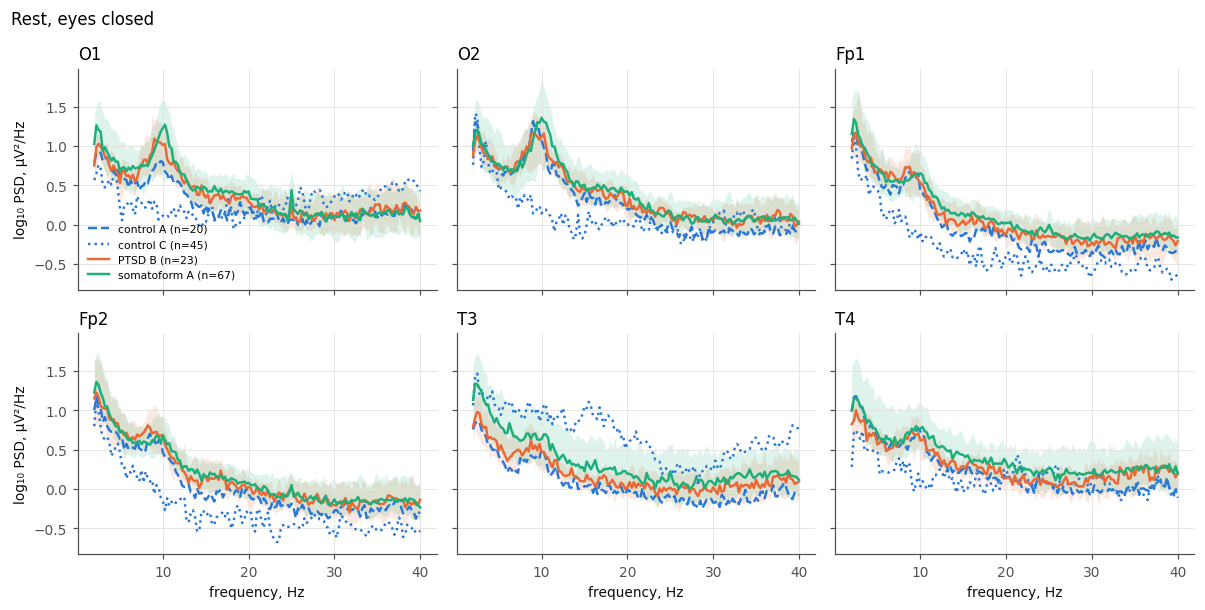

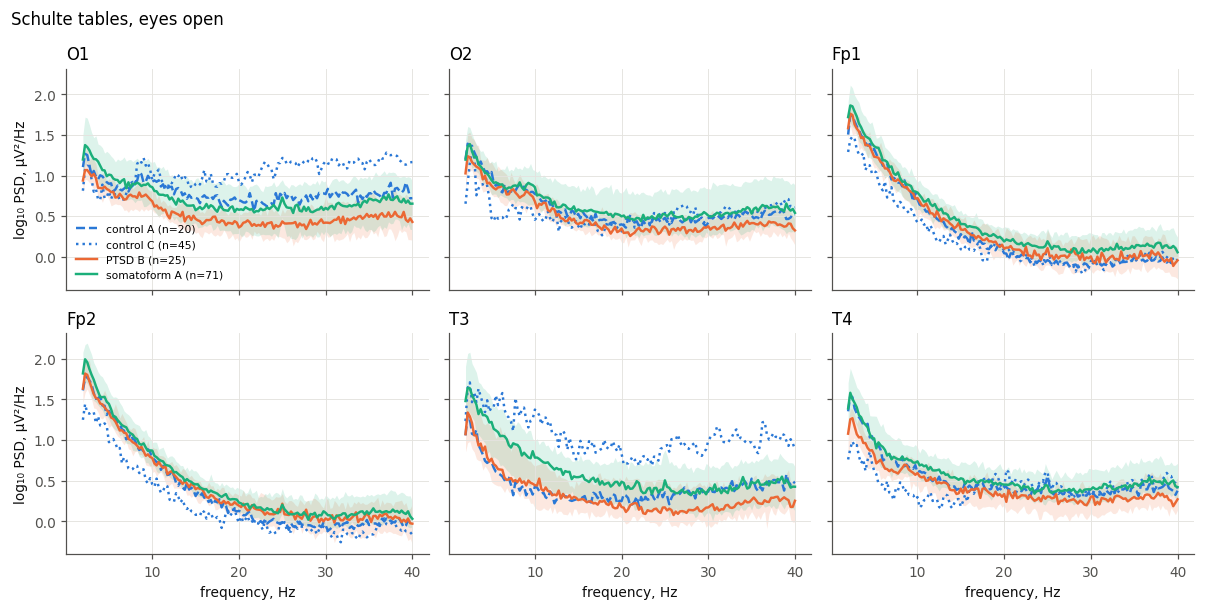

In [25]:
spec = features.compute_spectra(registry, cfg)
meta = registry.set_index("relpath").loc[list(spec.relpaths)].reset_index()
f = spec.freqs
band = (f >= 2.0) & (f <= 40.0)

def subject_spectra(condition: str) -> tuple[np.ndarray, pd.DataFrame]:
    idx = meta.index[(meta["condition"] == condition) & ~meta["condition_conflict"]]
    groups = meta.loc[idx].groupby("subject_key").groups
    keys_ = sorted(groups)
    stacked = np.stack([np.nanmedian(spec.spectra[list(groups[k])], axis=0) for k in keys_])
    return stacked, subjects.loc[keys_, ["group", "export_family"]]

strata = [(config.GROUP_CONTROL, "A", "--"), (config.GROUP_CONTROL, "C", ":"),
          (config.GROUP_PTSD, "B", "-"), (config.GROUP_SOMATOFORM, "A", "-")]
for condition, title in [("rest", "Rest, eyes closed"), ("task", "Schulte tables, eyes open")]:
    s, info = subject_spectra(condition)
    fig, axes = plt.subplots(2, 3, figsize=(11, 5.6), sharex=True, sharey=True)
    for ax, ch_idx in zip(axes.ravel(), [0, 5, 2, 3, 1, 4]):
        for cohort, fam, style in strata:
            sel = ((info["group"] == cohort) & (info["export_family"] == fam)).to_numpy() & np.isfinite(s[:, ch_idx, band]).all(axis=1)
            viz.plot_median_spectra(ax, f[band], s[sel, ch_idx][:, band], f"{viz.english(cohort)} {fam}", viz.COHORT_COLORS[cohort],
                                    style, band=style == "-")
        ax.set_title(config.CHANNELS[ch_idx], loc="left")
        ax.label_outer()
    axes[0, 0].legend(loc="lower left", fontsize=7)
    fig.suptitle(title, x=0.01, ha="left")
    plt.tight_layout()
    plt.show()

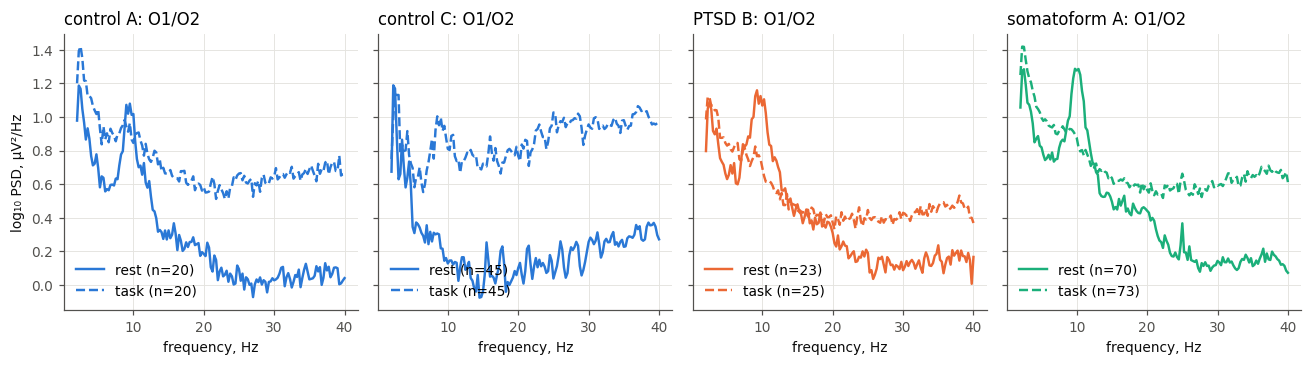

In [26]:
rest_s, rest_info = subject_spectra("rest")
task_s, task_info = subject_spectra("task")
occ = [config.CHANNELS.index("O1"), config.CHANNELS.index("O2")]
fig, axes = plt.subplots(1, 4, figsize=(12, 3.4), sharey=True)
for ax, (cohort, fam, _) in zip(axes, strata):
    for s, info, style, label in [(rest_s, rest_info, "-", "rest"), (task_s, task_info, "--", "task")]:
        sel = ((info["group"] == cohort) & (info["export_family"] == fam)).to_numpy()
        occipital = np.nanmean(s[sel][:, occ], axis=1)
        viz.plot_median_spectra(ax, f[band], occipital[:, band], label, viz.COHORT_COLORS[cohort], style, band=False)
    ax.set_title(f"{viz.english(cohort)} {fam}: O1/O2", loc="left")
    ax.legend(loc="lower left")
    ax.label_outer()
plt.tight_layout()
plt.show()

## 1.10 Summary of the original release

- 166 subject IDs form 158 independent groups. Five files are empty and eleven have a conflicting condition.
- The export format almost encodes the label: all PTSD patients are in format B, and the rule "format B means PTSD" reaches AUC 0.985. A high AUC alone therefore proves nothing about physiology.
- Format C (45 controls) does not look like typical EEG: no inter-channel correlation, no alpha, equal trial lengths. The cause is unknown.
- Age is mixed up with format: most controls older than 45 are in format C.
- Patients with PTSD solve the first table more slowly than controls and somatoform patients.
- Recording quality depends on the cohort (patients lose more windows), so it is not given to the model.

Feature hypotheses from the literature:

| Feature | Leads | Rationale |
| --- | --- | --- |
| alpha peak frequency and height | O1 | shifted and weaker alpha in PTSD (Kovacevic et al., 2025) |
| spectral slope | all | aperiodic background (Donoghue et al., 2020) |
| relative theta, alpha and beta power | all | classic markers, independent of channel gain |
| frontal alpha asymmetry | Fp1, Fp2 | approach and avoidance model (Davidson); Fp leads are sensitive to eye movements |
| Schulte solve time | | evaluated separately, with and without EEG |

Connectivity and microstates are not used. With six dry electrodes and a shared reference, channel correlation mostly reflects the reference (and is absent in format C), and microstates need dense topography.

## 1.11 Later batches: controls aged 65+ and supplementary controls

This section was added later and is also descriptive. It led to two decisions of protocol 2: the rule for copied channels and the exclusion of O2.

In [27]:
ok_all = registry_all[registry_all["status"] == "ok"]
subjects_all["batch"] = np.select(
    [subjects_all["holdout"], ~subjects_all["has_task_files"]], ["controls 65+", "suppl. controls"], "original release")
subjects_all["export_family"] = ok_all.groupby("subject_key")["export_family"].agg(lambda s: "".join(sorted(set(s))))
new_keys = subjects_all.index[subjects_all["batch"] != "original release"]
new_reg = registry_all[registry_all["subject_key"].isin(new_keys)].merge(
    subjects_all[["batch"]], left_on="subject_key", right_index=True)
new_ok = new_reg[new_reg["status"] == "ok"]
touched = links["subject_a"].isin(new_keys) | links["subject_b"].isin(new_keys)
status = new_reg["status"].value_counts().to_dict()
print(f"Recordings shared with other subjects: {int(touched.sum())}; files by status: {status} "
      "(missing means trials these batches did not record)")
print("File names:", new_ok["file_name"].value_counts().to_dict())
new_ok.groupby(["batch", "stem"]).agg(
    subjects=("subject_key", "nunique"), format=("export_family", lambda v: sorted(set(v))),
    sfreq_hz=("sfreq", lambda v: sorted(set(v))), zero_edge=("edge_constant_s", lambda v: int((v >= 0.1).sum())),
    median_length_s=("active_duration_s", "median"))

Recordings shared with other subjects: 0; files by status: {'missing': 292, 'ok': 86} (missing means trials these batches did not record)
File names: {'T-П.edf': 45, 'Т-П.edf': 18, 'Т-1.edf': 18, 'T-1.edf': 5}


subjects format sfreq_hz  zero_edge  median_length_s
batch           stem                                                      
controls 65+    T-1         23    [B]  [125.0]         22           113.74
                T-П         23    [B]  [125.0]         16            61.01
suppl. controls T-П         40    [B]  [125.0]         37            61.00

In [28]:
subjects_all[subjects_all["group"] == config.GROUP_CONTROL].groupby("batch")["age"].describe()[["count", "min", "50%", "max"]]

,count,min,50%,max
batch,,,,
controls 65+,23.0,65.0,68.0,70.0
original release,67.0,19.0,32.0,58.0
suppl. controls,40.0,17.0,19.5,41.0


Both batches are format B, like the PTSD group, so the format rule becomes weaker. But they also differ from the original format B recordings, as shown below.

In [29]:
young_pair = subjects_all[subjects_all["group"].isin([config.GROUP_CONTROL, config.GROUP_PTSD]) & ~subjects_all["holdout"]]
print(f"AUC of the format B rule, all controls under 65: "
      f"{roc_auc_score(young_pair['label'], young_pair['export_family'] == 'B'):.3f} "
      f"(PTSD {int(young_pair['label'].sum())}, controls {int((young_pair['label'] == 0).sum())})")

AUC of the format B rule, all controls under 65: 0.804 (PTSD 25, controls 107)


**Copied channels.** A channel that is byte-identical to another channel of the same recording is excluded together with its pair.

In [30]:
qc_new = preprocessing.rejection_table(new_reg, cfg).merge(new_reg[["relpath", "batch"]], on="relpath")
copies = qc_new[qc_new["frac_copy"] > 0].groupby(["batch", "relpath"])["channel"].agg(", ".join)
print("Recordings with copied channels:", copies.groupby(level=0).size().to_dict())
copies.to_frame("copied channels").rename(index=viz.english)

Recordings with copied channels: {'controls 65+': 2, 'suppl. controls': 12}


copied channels
batch           relpath                                  
controls 65+    control/A003_68/T-1.edf            T3, O2
                control/A003_68/T-П.edf            T3, O2
suppl. controls control/КС205_22/T-П.edf           T3, T4
                control/КС217_18/T-П.edf           T3, T4
                control/КС224_18/T-П.edf           T3, O2
                control/КС225_19/T-П.edf           T3, O2
                control/КС227_20/T-П.edf       T3, T4, O2
                control/КС229_40/T-П.edf           T3, T4
                control/КС230_21/T-П.edf           T3, O2
                control/КС233_20/T-П.edf           T3, O2
                control/КС234_19/T-П.edf       T3, T4, O2
                control/КС238м_18/T-П.edf          T3, O2
                control/КС239м_19/T-П.edf          T3, O2
                control/КС240м_20/T-П.edf          T3, O2

**EEG properties by batch**, the same checks plus the O2–Fp2 correlation.

In [31]:
plaus_new = diagnostics.plausibility_table(new_reg[new_reg["stem"] == config.REST_STEM], cfg).merge(
    new_reg[["relpath", "batch"]], on="relpath")
reference = plaus.assign(batch=plaus["group"].map(viz.COHORT_LABELS) + " " + plaus["export_family"])
both = pd.concat([reference, plaus_new], ignore_index=True)
cols = ["O1-O2", "Fp1-Fp2", "O2-Fp2", "alpha_prominence_occ", "t3_rms_ratio"]
table_new = both.groupby("batch")[cols].median()
table_new["share O2–Fp2 > 0.6"] = both.groupby("batch")["O2-Fp2"].apply(lambda v: (v > 0.6).mean())
table_new["share with alpha peak > 0.4"] = both.groupby("batch")["alpha_prominence_occ"].apply(lambda v: (v > 0.4).mean())
table_new["recordings"] = both.groupby("batch").size()
table_new

,O1-O2,Fp1-Fp2,O2-Fp2,alpha_prominence_occ,t3_rms_ratio,share O2–Fp2 > 0.6,share with alpha peak > 0.4,recordings
batch,,,,,,,,
PTSD B,6.13e-01,0.89,1.36e-01,0.83,0.84,0.04,0.88,25
control A,5.03e-01,0.84,1.51e-01,0.91,0.81,0.00,0.80,20
control B,6.12e-01,0.80,6.63e-02,1.15,0.81,0.00,0.50,2
control C,-8.97e-04,0.02,-2.26e-03,0.19,2.79,0.00,0.00,45
controls 65+,5.08e-01,0.81,4.11e-01,0.23,1.00,0.26,0.17,23
somatoform A,5.21e-01,0.78,1.57e-01,0.74,0.97,0.01,0.81,74
suppl. controls,2.07e-02,0.80,8.35e-01,0.70,1.00,0.68,0.82,40


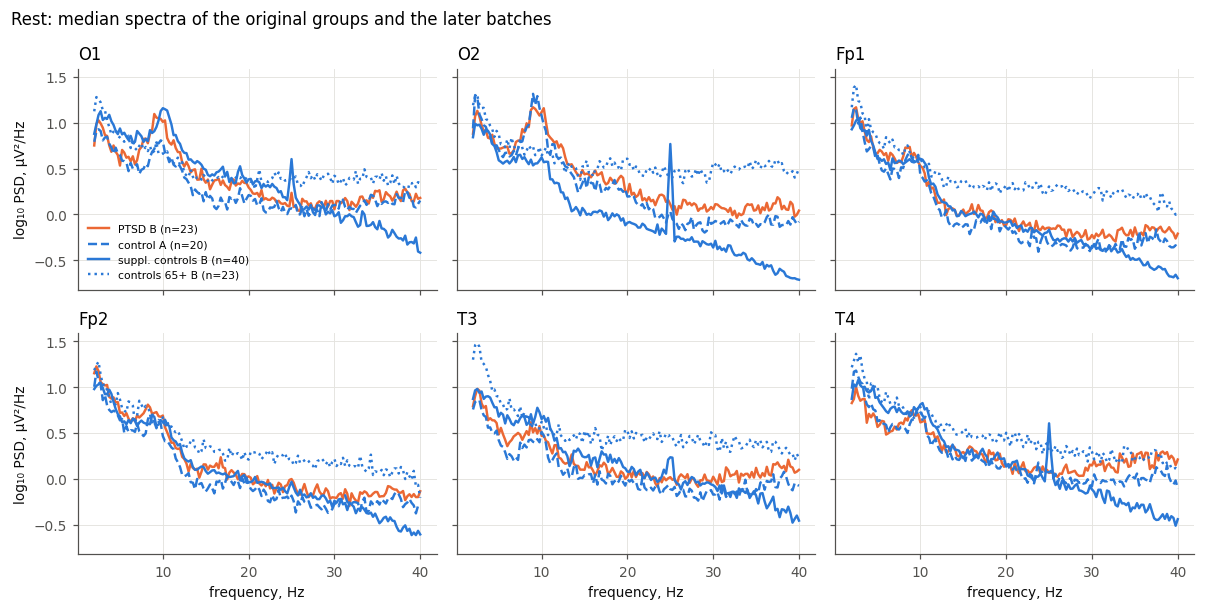

In [32]:
spec_new = features.compute_spectra(new_reg[new_reg["stem"] == config.REST_STEM], cfg)
new_batch = new_reg.set_index("relpath").loc[list(spec_new.relpaths), "batch"].to_numpy()
rest_meta = meta[(meta["condition"] == "rest") & ~meta["condition_conflict"]]
curves = [
    ("PTSD B", spec.spectra[rest_meta.index[rest_meta["group"] == config.GROUP_PTSD]], viz.COHORT_COLORS[config.GROUP_PTSD], "-"),
    ("control A", spec.spectra[rest_meta.index[(rest_meta["group"] == config.GROUP_CONTROL) & (rest_meta["export_family"] == "A")]],
     viz.COHORT_COLORS[config.GROUP_CONTROL], "--"),
    ("suppl. controls B", spec_new.spectra[new_batch == "suppl. controls"], viz.COHORT_COLORS[config.GROUP_CONTROL], "-"),
    ("controls 65+ B", spec_new.spectra[new_batch == "controls 65+"], viz.COHORT_COLORS[config.GROUP_CONTROL], ":"),
]
fig, axes = plt.subplots(2, 3, figsize=(11, 5.6), sharex=True, sharey=True)
for ax, ch_idx in zip(axes.ravel(), [0, 5, 2, 3, 1, 4]):
    for label, s, color, style in curves:
        s = s[:, ch_idx][:, band]
        viz.plot_median_spectra(ax, f[band], s[np.isfinite(s).all(axis=1)], label, color, style, band=False)
    ax.set_title(config.CHANNELS[ch_idx], loc="left")
    ax.label_outer()
axes[0, 0].legend(loc="lower left", fontsize=7)
fig.suptitle("Rest: median spectra of the original groups and the later batches", x=0.01, ha="left")
plt.tight_layout()
plt.show()

**Solve time of the first table** (without format C).

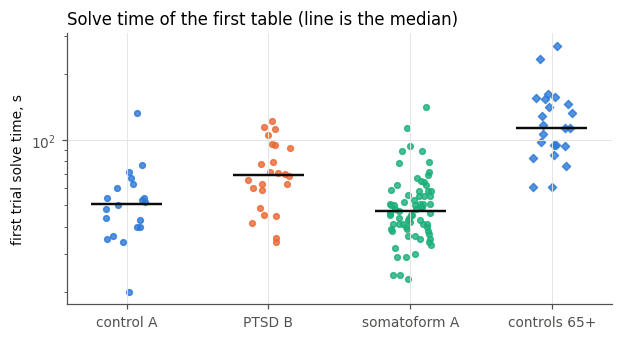

,count,25%,50%,75%
stratum,,,,
control A,20.0,40.00,51.00,60.75
PTSD B,24.0,56.20,69.06,92.64
somatoform A,71.0,39.50,47.00,57.00
controls 65+,23.0,94.12,113.74,150.25


In [33]:
trial1 = ok_all[(ok_all["stem"] == "T-1") & (ok_all["export_family"] != "C") & ~ok_all["condition_conflict"]].merge(
    subjects_all[["batch"]], left_on="subject_key", right_index=True)
trial1 = trial1.assign(stratum=np.where(trial1["batch"] == "controls 65+", "controls 65+",
                                        trial1["group"].map(viz.COHORT_LABELS) + " " + trial1["export_family"]))
order = ["control A", "PTSD B", "somatoform A", "controls 65+"]
colors = [viz.COHORT_COLORS[config.GROUP_CONTROL], viz.COHORT_COLORS[config.GROUP_PTSD],
          viz.COHORT_COLORS[config.GROUP_SOMATOFORM], viz.COHORT_COLORS[config.GROUP_CONTROL]]
fig, ax = plt.subplots(figsize=(6.4, 3.2))
rng = np.random.default_rng(0)
for i, (name, color) in enumerate(zip(order, colors)):
    v = trial1.loc[trial1["stratum"] == name, "active_duration_s"].to_numpy()
    ax.scatter(i + rng.uniform(-0.15, 0.15, v.size), v, s=14, color=color, alpha=0.8,
               marker="o" if name != "controls 65+" else "D")
    ax.hlines(np.median(v), i - 0.25, i + 0.25, color="#0b0b0b", lw=1.6)
ax.set_xticks(range(len(order)), order)
ax.set_yscale("log")
ax.set_ylabel("first trial solve time, s")
ax.set_title("Solve time of the first table (line is the median)", loc="left")
plt.show()
trial1.groupby("stratum")["active_duration_s"].describe()[["count", "25%", "50%", "75%"]].reindex(order)

### Summary of the later batches

- Controls aged 65+ have typical channel correlations, but a clear alpha peak in only a few recordings, as expected with age. They solve the first table more slowly than anyone, so solve time alone would mistake them for PTSD.
- In the supplementary controls some files have copied channels, O2 behaves like a frontal channel, and the spectrum has a narrow peak at 25 Hz and falls steeply towards 40 Hz. These are signs of a different recording setup.
- The format rule weakens, but separating PTSD from the new batch may reflect the batch rather than the diagnosis. Notebook 4 tests this.